# Mandıra Üretim Optimizasyonu: Doğrusal ve Lineer Olmayan Modellerin Karşılaştırmalı Analizi

## 1. Çalışmanın Amacı
Bu çalışma, kısıtlı kaynaklara (süt, meyve, şeker) sahip bir mandıranın üretim planlamasını iki farklı senaryo altında optimize etmeyi amaçlamaktadır. Problem, **Doğrusal Programlama (Linear Programming)** ve **Lineer Olmayan Programlama (Non-Linear Programming)** tekniklerinin Python üzerinde hibrit bir şekilde uygulanmasını gerektirmektedir.

## 2. Metodoloji ve Algoritmik Yaklaşım

Çözüm süreci, problemin matematiksel yapısına uygun olarak iki aşamada kurgulanmıştır:

### A. Gelir Maksimizasyonu (Doğrusal Model)
* **Amaç Fonksiyonu:** $Z = 4x_A + 5x_B$ (Doğrusal)
* **Yöntem:** Problemin yapısı doğrusal olduğu için endüstri standardı olan **Simpleks Algoritması** tercih edilmiştir.
* **Kod Uygulaması:** `scipy.optimize.linprog` kütüphanesi ve modern `highs` metodu kullanılarak, olurlu bölgenin köşe noktaları taranmış ve global optimum nokta tespit edilmiştir.

### B. Fayda Maksimizasyonu (Lineer Olmayan Model)
* **Amaç Fonksiyonu:** $Z = x_A \cdot x_B$ (Eğrisel / Non-Linear)
* **Yöntem:** Amaç fonksiyonu eğrisel olduğu için Simpleks algoritması kullanılamaz. Bunun yerine türev tabanlı **Lagrange Çarpanları (KKT - Karush-Kuhn-Tucker)** koşullarını sağlayan nümerik yöntemler kullanılmıştır.
* **Kod Uygulaması:** `scipy.optimize.minimize` kütüphanesi ve **SLSQP (Sequential Least Squares Programming)** algoritması kullanılmıştır. Bu algoritma, kısıtlı non-linear optimizasyon problemlerinde gradyan (eğim) bilgisini kullanarak teğet noktasını (optimum) bulur.

## 3. Görselleştirme ve Analiz
Elde edilen sayısal sonuçların doğruluğunu ve kararlılığını (stability) kanıtlamak amacıyla `Matplotlib` kullanılarak görsel bir analiz yapılmıştır:

1.  **Olurlu Bölge (Feasible Region):** Meyve, Süt ve Şeker kısıtlarının oluşturduğu kapalı alan yeşil renk ile taranmıştır.
2.  **Kısıt Analizi:** Her bir kaynağın sınırları (doğrular) çizilerek optimum noktanın hangi kısıtların kesişiminde oluştuğu gösterilmiştir.
3.  **Çözümün Kanıtı:**
    * **Mavi Doğru:** Doğrusal gelir fonksiyonunu temsil eder.
    * **Mor Eğri:** Lineer olmayan fayda fonksiyonunu (hiperbol) temsil eder.
    * Grafik, her iki fonksiyonun da matematiksel yapısı farklı olmasına rağmen, kısıtların baskınlığı nedeniyle aynı köşe noktasına **(300, 200)** teğet geçtiğini ve optimum çözümün değişmediğini görsel olarak ispatlamaktadır.

HİBRİT ÇÖZÜM VE GÖRSEL ANALİZ
1. GELİR MAKSİMİZASYONU (SIMPLEKS ALGORİTMASI)
-> Çözüm Durumu: Başarılı
-> Optimal A Tipi Üretim: 300.00 adet
-> Optimal B Tipi Üretim: 200.00 adet
-> MAKSİMUM GELİR:      2200.00 TL
2. FAYDA MAKSİMİZASYONU (LAGRANGE / KKT YAKLAŞIMI)
-> Çözüm Durumu: Başarılı (KKT Koşulları Sağlandı)
-> Optimal A Tipi Üretim: 300.0000 adet
-> Optimal B Tipi Üretim: 200.0000 adet
-> MAKSİMUM FAYDA:      60000.0000 Birim

[SONUÇ ANALİZİ]: Her iki yöntem de kısıtların kesişim noktası olan
(300, 200) noktasına yakınsamıştır.


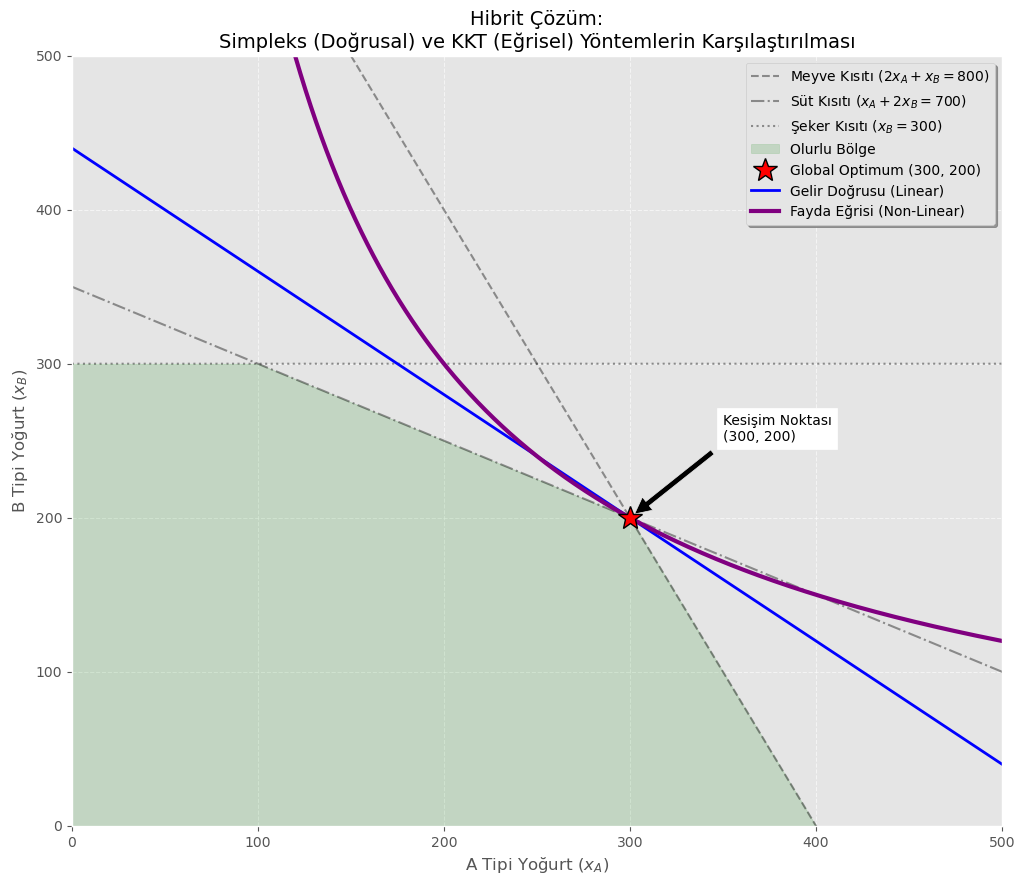

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

# 1.GRAFİK AYARLARI
plt.rcParams['figure.figsize'] = (12, 10)
plt.style.use('ggplot')

def optimization_bonus_2():
    print("HİBRİT ÇÖZÜM VE GÖRSEL ANALİZ")

    # BÖLÜM 1: HESAPLAMA

    # SENARYO A: DOĞRUSAL PROGRAMLAMA (SIMPLEKS)
    print("1. GELİR MAKSİMİZASYONU (SIMPLEKS ALGORİTMASI)")
    
    # Max Z = 4xA + 5xB  => Scipy minimize yaptığı için katsayılar negatif (-4, -5)
    c_linear = [-4, -5]
    
    # Kısıtlar (Ax <= b)
    A_constraints = [
        [2, 1],  # Meyve: 2xA + xB <= 800
        [1, 2],  # Süt:   xA + 2xB <= 700
        [0, 1]   # Şeker: xB <= 300
    ]
    b_limits = [800, 700, 300]
    
    # Sınırlar (x >= 0)
    bounds = (0, None)
    
    # Çözüm
    res_lin = linprog(c_linear, A_ub=A_constraints, b_ub=b_limits, bounds=[bounds, bounds], method='highs')
    
    # Sonuçları Sakla
    opt_xA_lin = res_lin.x[0]
    opt_xB_lin = res_lin.x[1]
    max_income = -res_lin.fun
    
    if res_lin.success:
        print(f"-> Çözüm Durumu: Başarılı")
        print(f"-> Optimal A Tipi Üretim: {opt_xA_lin:.2f} adet")
        print(f"-> Optimal B Tipi Üretim: {opt_xB_lin:.2f} adet")
        print(f"-> MAKSİMUM GELİR:      {max_income:.2f} TL")
    else:
        print("Hata: Doğrusal problem çözülemedi.")
    

    # SENARYO B: LİNEER OLMAYAN PROGRAMLAMA (KKT)
    print("2. FAYDA MAKSİMİZASYONU (LAGRANGE / KKT YAKLAŞIMI)")
    
    # Amaç: Max Z = xA * xB => Minimize (-xA * xB)
    def objective_func(x):
        return -(x[0] * x[1])
    
    # Kısıtlar (Scipy formatı: fun(x) >= 0)
    constraints = [
        {'type': 'ineq', 'fun': lambda x: 800 - (2*x[0] + x[1])}, # Meyve
        {'type': 'ineq', 'fun': lambda x: 700 - (1*x[0] + 2*x[1])}, # Süt
        {'type': 'ineq', 'fun': lambda x: 300 - x[1]}             # Şeker
    ]
    
    x0 = [10, 10] # Başlangıç tahmini
    
    # Çözüm
    res_non = minimize(objective_func, x0, method='SLSQP', bounds=[bounds, bounds], constraints=constraints)
    
    # Sonuçları Sakla
    opt_xA_non = res_non.x[0]
    opt_xB_non = res_non.x[1]
    max_utility = -res_non.fun
    
    if res_non.success:
        print(f"-> Çözüm Durumu: Başarılı (KKT Koşulları Sağlandı)")
        print(f"-> Optimal A Tipi Üretim: {opt_xA_non:.4f} adet")
        print(f"-> Optimal B Tipi Üretim: {opt_xB_non:.4f} adet")
        print(f"-> MAKSİMUM FAYDA:      {max_utility:.4f} Birim")
        print(f"\n[SONUÇ ANALİZİ]: Her iki yöntem de kısıtların kesişim noktası olan")
        print(f"(300, 200) noktasına yakınsamıştır.")
    else:
        print("Hata: Lineer olmayan problem çözülemedi.")

    # BÖLÜM 2: GÖRSELLEŞTİRME
    
    # Eksen verisi
    x = np.linspace(0, 800, 2000)
    
    # Kısıt Doğruları
    y_fruit = 800 - 2*x          # Meyve
    y_milk = (700 - x) / 2       # Süt
    y_sugar = np.full_like(x, 300) # Şeker
    
    # Olurlu Bölge (En altta kalan alan)
    y_constraints = np.minimum(y_fruit, y_milk)
    y_constraints = np.minimum(y_constraints, y_sugar)
    y_feasible = np.maximum(y_constraints, 0)
    
    plt.figure()
    
    # 1. Kısıt Çizgileri
    plt.plot(x, y_fruit, 'k--', alpha=0.4, label='Meyve Kısıtı ($2x_A+x_B=800$)')
    plt.plot(x, y_milk, 'k-.', alpha=0.4, label='Süt Kısıtı ($x_A+2x_B=700$)')
    plt.plot(x, y_sugar, 'k:', alpha=0.4, label='Şeker Kısıtı ($x_B=300$)')
    
    # 2. Olurlu Bölge (Yeşil Alan)
    plt.fill_between(x, 0, y_feasible, where=(y_feasible>0), color='green', alpha=0.15, label='Olurlu Bölge')
    
    # 3. Optimal Nokta (Simpleks ve KKT aynı yeri buldu)
    plt.plot(opt_xA_lin, opt_xB_lin, 'r*', markersize=18, markeredgecolor='black', zorder=10, 
             label=f'Global Optimum ({opt_xA_lin:.0f}, {opt_xB_lin:.0f})')
    
    # 4. AMAÇ FONKSİYONLARI (ÇÖZÜMÜN KANITI)
    
    # A) Gelir Doğrusu (Mavi - Düz)
    # Z = 4x + 5y => y = (Z - 4x) / 5
    y_income = (max_income - 4*x) / 5
    plt.plot(x, y_income, color='blue', linewidth=2, linestyle='-', label='Gelir Doğrusu (Linear)')
    
    # B) Fayda Eğrisi (Mor - Kavisli)
    # Z = x*y => y = Z / x
    with np.errstate(divide='ignore'):
        y_utility = max_utility / x
    plt.plot(x, y_utility, color='purple', linewidth=3, linestyle='-', label='Fayda Eğrisi (Non-Linear)')
    
    # Grafik Düzeni
    plt.xlim(0, 500)
    plt.ylim(0, 500)
    plt.xlabel('A Tipi Yoğurt ($x_A$)', fontsize=12)
    plt.ylabel('B Tipi Yoğurt ($x_B$)', fontsize=12)
    plt.title('Hibrit Çözüm:\nSimpleks (Doğrusal) ve KKT (Eğrisel) Yöntemlerin Karşılaştırılması', fontsize=14)
    plt.legend(loc='upper right', shadow=True, fancybox=True)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Açıklayıcı ok
    plt.annotate('Kesişim Noktası\n(300, 200)', xy=(300, 200), xytext=(350, 250),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, backgroundcolor='white')
    
    plt.show()

if __name__ == "__main__":
    optimization_bonus_2()
    